# Streaming fresh minibatches

The memorization benchmark reused one minibatch for the whole run, so it measured raw
optimization power on a fixed objective. Here a fresh minibatch is drawn every step
instead, so the run is actually training on CIFAR-10 and the question becomes
generalization: how low does the held-out loss go, and how fast? I compare three runs on
gelu: the trust-region optimizer, the same trust region built on the Gauss-Newton matrix
rather than the Hessian, and plain SGD. The trust-region and SGD runs keep the settings
that worked best in the memorization benchmark, because those are the ones worth carrying
over. The signal to read is the loss on a fixed held-out probe batch, not the training
loss, because the training loss is measured on a different minibatch every step and is
too noisy to follow.

## The configuration

The model and data match the memorization benchmark exactly, and the only change is
dropping `--reuse-batch`, so a new minibatch is drawn every step:

```
--image-size 8 --hidden-dim 8 --num-layers 16 --batch-size 32 --seed 0 --data-dir ./data
```

There are three runs, all on gelu. The trust-region run uses the dense subproblem solver,
`--mode trust-region --tr-solver dense --delta-init 1.0 --delta-max 100 --tr-eta 0.1 --num-steps 400`,
and sweeping its trust-radius and acceptance parameters on this streaming task did not
move it, so it keeps the radius that worked for memorization. The Gauss-Newton run adds
`--curvature ggn` to those same arguments and changes nothing else, so the only thing
separating the two is which matrix the subproblem is built on: the Hessian, which is
indefinite away from a minimum, or `G = J'ΛJ`, which drops the network's own curvature
and is therefore positive semidefinite. The SGD run uses
`--mode sgd --lr 0.1 --num-steps 30000`, whose learning rate is tuned on this streaming
objective rather than carried over, because the memorization rate of 0.03 was too small
here and only started descending after about 17000 steps. The exact args live in
`streaming/experiments.py`, which both `run.py` and `plot.py` import.

## Running it

The figure below renders inline from the committed CSVs. To regenerate the data, run
`python benchmarks/streaming/run.py` from the repo root using the project venv. That
script launches `src/train_newton.py` once per config, parses its per-step stderr, and
writes `streaming/results/<name>.csv` with columns
`step,train_loss,probe_loss,probe_accuracy,wall_clock_s`. The cell below then renders the
figure by importing `plot`.

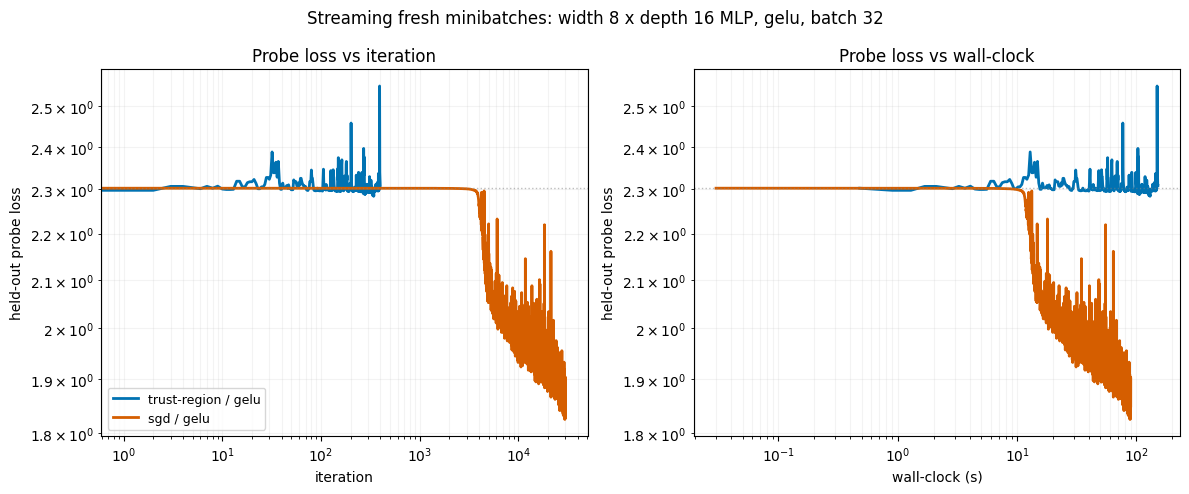

In [1]:
import pathlib, sys

for cand in (pathlib.Path.cwd() / "streaming",
             pathlib.Path.cwd() / "benchmarks" / "streaming"):
    if cand.exists():
        sys.path.insert(0, str(cand))
        break

%matplotlib inline
import plot

fig = plot.build_figure()

## The result

| Run      | Method            | Best probe loss | Step at best | Wall-clock at best | Best probe acc |
|----------|-------------------|-----------------|--------------|--------------------|----------------|
| tr_gelu  | trust-region      | 2.2844          | 341          | 129.5 s            | 0.148          |
| ggn_gelu | trust-region-ggn  | 2.2916          | 11           | 3.4 s              | 0.176          |
| sgd_gelu | sgd               | 1.8247          | 29590        | 88.4 s             | 0.336          |

The result flips from the memorization benchmark, because here SGD wins. SGD drives the
held-out probe loss down to 1.82, reaching 34% probe accuracy, whereas neither
trust-region variant gets below 2.28 and both mostly thrash around the random-guess loss
of ln(10) ≈ 2.30, so they barely learn at all. The runs take very different iteration
counts, so the wall-clock panel is the fair comparison, and at roughly equal wall-clock
(about 130 s for trust-region's 400 steps against 88 s for SGD's 30000) SGD is already
far ahead.

This is the minibatch-noise effect from the stochastic-optimization literature. The
trust-region step is computed from one noisy minibatch and its acceptance ratio is checked
on that same batch, so it fits the curvature of a different objective every step, and a
second-order method loses its edge once the gradient and Hessian are dominated by that
noise. Sweeping the trust-region radius and acceptance threshold did not change this,
which says the stall is the noise rather than the tuning. The memorization benchmark
removed the noise by reusing one batch, which is exactly why trust-region won there and
loses here.

Swapping the Hessian for the Gauss-Newton matrix does what it is supposed to do at the
level of the subproblem without rescuing the run. Over a separate 80-step diagnostic run
of each, the Gauss-Newton subproblem accepted 66 of 80 steps against the Hessian's 56, and
needed far less damping to reach the trust-region boundary, with a final λ* of 0.91
against 45.8, both of which follow from `G` being positive semidefinite where the Hessian
is not: its spectrum came out in [-2.9e-09, 2.1e-02] while the Hessian's spanned
[-7.8, 70.2]. But the trust radius collapses to 1.6e-02 in both runs, so the extra
accepted steps are tiny ones and the probe loss goes nowhere. The bottleneck is the same
minibatch noise in both cases, and definiteness of the curvature matrix does not address
it. What this benchmark can say about the Gauss-Newton matrix is therefore limited,
because it is being compared against a trust region that does not work here either.